<h1>MonReader: Single Frame Modelling (SFM): Model Training

In [1]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
TRAIN_DATA_DIR = RAW_DATA_DIR / "training"
TEST_DATA_DIR = RAW_DATA_DIR / "testing"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
SFM_DATA_DIR = PROCESSED_DATA_DIR / "sfm"

MODELS_DIR = PROJ_ROOT / "models"
SFM_MODELS_DIR = MODELS_DIR / "sfm"

In [2]:
import pickle

pkl_data = {}

for pkl_file in SFM_DATA_DIR.glob("*.pkl"):
    with pkl_file.open("rb") as file:
        pkl_data[pkl_file.stem] = pickle.load(file)

print(f"Loaded {len(pkl_data)} pickle files:")
print(list(pkl_data))

Loaded 4 pickle files:
['X_test', 'X_train', 'y_test', 'y_train']


In [3]:
X_train = pkl_data['X_train']
y_train = pkl_data['y_train']
X_test = pkl_data['X_test']
y_test = pkl_data['y_test']

Shuffle the sets as lots of the images will be a sequence of frames of the same clip. We are working with SFM so don't want sequences of similar frames to cause overfitting:

In [4]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(
    X_train,
    y_train,
    random_state=13
)

Generate a validation set (make sure it is random) + confirm correct image shapes:

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train)

for name in ["X_train", "X_val", "y_train", "y_val", "X_test", "y_test"]:
    value = globals()[name]
    if hasattr(value, "shape"):
        print(f"{name}: {value.shape}")
    else:
        print(f"{name}: {type(value)}")

X_train: (1913, 480, 270, 1)
X_val: (479, 480, 270, 1)
y_train: (1913,)
y_val: (479,)
X_test: (597, 480, 270, 1)
y_test: (597,)


Using Tensorflow models

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
import matplotlib.pyplot as plt

Next is to build a starter CNN model. Below is a model that I made for a previous computer vision classification project which served well as a starter model:

In [11]:
model_1 = Sequential([

# First Convolutional Block
Conv2D(32 ,3, padding="same", activation='relu', input_shape=X_train[1].shape), #input shape = (h, w, channel) i.e. image size + channel
# ReLu allows non-linearity to be considered
# Convo2D Applies small learnable **filters/kernels** across the image. Each filter learns to detect a particular spatial feature
BatchNormalization(), #Normalizes the intermediate layer activations per batch (helps to speed training)
Conv2D(32, 3, activation='relu'), # ''
MaxPooling2D(), #Reduces spatial dimension by X (H x W -> H/X x w/X). Reduces computation
Dropout(0.2), # Turn of random proportion of neurons to reduce overfitting.

# Second Convolutional Block
Conv2D(128, 3, padding='same',activation='relu'),
BatchNormalization(),
MaxPooling2D(),
Dropout(0.2),

# Flatten and Dense layers
GlobalAveragePooling2D(), # Reduces each feature map to a single value by taking its average across the spatial dimensions
Dense(32, activation="relu"),
BatchNormalization(),
Dropout(0.2),
Dense(2, activation='sigmoid')  # 2 classes for the target
])

# Compile the model
model_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall(),tf.keras.metrics.F1Score(), "accuracy"]
    )
# Display model summary
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 480, 270, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 480, 270, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 478, 268, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 239, 134, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 239, 134, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 239, 134, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 239, 134, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 119, 67, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 119, 67, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,522 (201.26 KB)

 Trainable params: 51,138 (199.76 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
# Implement early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=2
)

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=2)

trained_model = model_1.fit(
    X_train,
    y_train_cat,
    batch_size=64,
    epochs=10,
    shuffle=True,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stopping]
)


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 162s 5s/step - accuracy: 0.7376 - f1_score: 0.7366 - loss: 0.5593 - precision_3: 0.7223 - recall_3: 0.7329 - val_accuracy: 0.5574 - val_f1_score: 0.5496 - val_loss: 0.6922 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 168s 6s/step - accuracy: 0.8139 - f1_score: 0.8127 - loss: 0.4298 - precision_3: 0.8084 - recall_3: 0.8029 - val_accuracy: 0.4864 - val_f1_score: 0.3272 - val_loss: 0.7326 - val_precision_3: 0.4864 - val_recall_3: 0.4864
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 165s 5s/step - accuracy: 0.8468 - f1_score: 0.8461 - loss: 0.3815 - precision_3: 0.8455 - recall_3: 0.8385 - val_accuracy: 0.4864 - val_f1_score: 0.3272 - val_loss: 0.8474 - val_precision_3: 0.4864 - val_recall_3: 0.4864
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 165s 6s/step - accuracy: 0.8646 - f1_score: 0.8641 - loss: 0.3326 - precision_3: 0.8629 - recall_3: 0.8552 - val_accuracy: 0.4864 - val_f1_score: 0.3272 - val_loss: 1.0865 - val

*After training model_1 is updated, so call model_1 for making predictions. trained_model contains the training logs e.g validation and history which should be called when plotting training vs validation curves*

Evaluating the initial model:

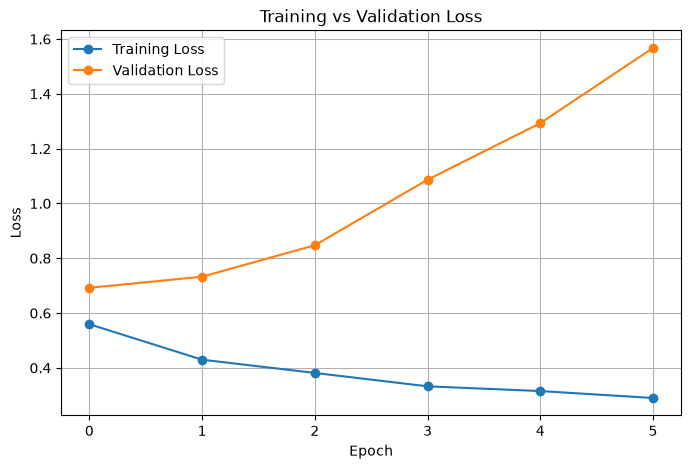

In [27]:
# Plot training & validation loss curves
def plot_training_history(trained_model, metric='loss'):
    """
    Plots training and validation curves for a given metric from a Keras History object.

    Parameters:
        trained_model: keras.callbacks.History object returned by model.fit()
        metric: str, the metric to plot (default 'loss')
    """
    history = trained_model.history
    val_metric = f"val_{metric}"

    if metric not in history or val_metric not in history:
        raise ValueError(f"Metric '{metric}' not found in training history.")

    plt.figure(figsize=(8, 5))
    plt.plot(history[metric], marker='o', label=f'Training {metric.capitalize()}')
    plt.plot(history[val_metric], marker='o', label=f'Validation {metric.capitalize()}')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.title(f'Training vs Validation {metric.capitalize()}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage:
plot_training_history(trained_model, metric='loss')

Test set evaluation:
  loss: 0.6921084523200989
  compile_metrics: 0.0
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 317ms/step

Classification Report:
              precision    recall  f1-score   support

     notflip       0.58      0.47      0.52       307
        flip       0.53      0.63      0.58       290

    accuracy                           0.55       597
   macro avg       0.55      0.55      0.55       597
weighted avg       0.55      0.55      0.55       597

Macro F1-score: 0.5474


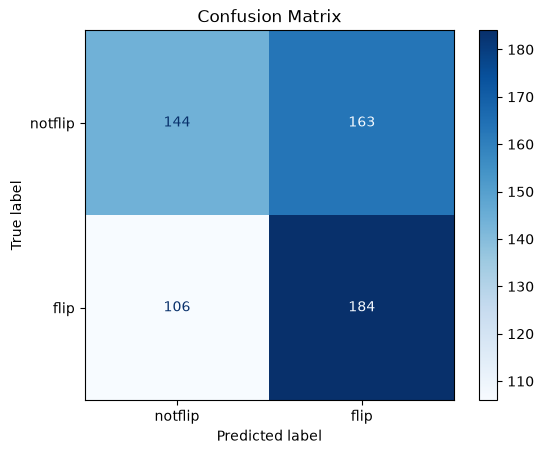

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay

def evaluate_model(model, X_test, y_test, class_names=("Class 0", "Class 1")):
    """
    Evaluate a trained Keras model on test data, printing loss/metrics,
    classification report, F1-score, and displaying a confusion matrix.

    Parameters
    ----------
    model : keras.Model
        Trained Keras model to evaluate.
    X_test : np.ndarray
        Test features.
    y_test : np.ndarray
        Test labels (integer-encoded, not one-hot).
    class_names : tuple of str
        Names for the classes, used in the confusion matrix display.

    Returns
    -------
    dict
        Dictionary containing test loss, accuracy, f1_score (macro),
        and the confusion matrix.
    """
    # One-hot encode y_test for model.evaluate
    y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=len(class_names))

    # Evaluate using Keras built-in metrics
    results = model.evaluate(X_test, y_test_cat, verbose=0)
    metric_names = model.metrics_names
    print("Test set evaluation:")
    for name, value in zip(metric_names, results):
        print(f"  {name}: {value}")

    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = y_pred_probs.argmax(axis=1)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # F1-score (macro)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    print(f"Macro F1-score: {macro_f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    return {
        "test_loss_metrics": dict(zip(metric_names, results)),
        "macro_f1": macro_f1,
        "confusion_matrix": cm
    }

eval_results = evaluate_model(model_1, X_test, y_test, class_names=('notflip', 'flip'))

This divergence is classic overfitting behaviour. The next steps will be to consider what parts of the model are causing this overfitting and to address them. Let's save the model for now.

In [29]:
import os

def save_model(file_path, model, history=None):
    """
    Save a Keras model (and optionally its training history) to disk.

    Parameters
    ----------
    file_path : str
        Destination path for the model file. Saved in the native Keras
        format (`.keras`). Parent directories are created automatically
        if they do not exist.
    model : keras.Model
        Trained Keras model to save.
    history : keras.callbacks.History or dict, optional
        Training history to save alongside the model. If provided, it is
        pickled to a `.pkl` file with the same base name as `file_path`.

    Returns
    -------
    None
        This function writes the model (and optionally history) to disk
        and prints confirmation messages.
    """
    file_path = str(file_path)
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    # Ensure correct extension for native Keras format
    if not file_path.endswith(".keras"):
        file_path = os.path.splitext(file_path)[0] + ".keras"

    model.save(file_path)
    print(f"Saved model to '{file_path}'")

    # Print size of saved model file in MB
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"Model size: {size_mb:.2f} MB")

    # Print estimated serialized history size
    if history is not None:
        history_dict = history.history if hasattr(history, "history") else history
        history_size_mb = len(pickle.dumps(history_dict)) / (1024 * 1024)
        print(f"History size: {history_size_mb:.4f} MB")

    if history is not None:
        history_dict = history.history if hasattr(history, "history") else history
        history_path = os.path.splitext(file_path)[0] + "_history.pkl"

        with open(history_path, "wb") as f:
            pickle.dump(history_dict, f)

        print(f"Saved history to '{history_path}'")

model_path = SFM_MODELS_DIR / 'model_1' # Don't worry about .pkl or .keras at the end, the function will take care of it.
save_model(model_path, model_1, model_1.history)

Saved model to 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_1.keras'
Model size: 0.65 MB
History size: 0.0011 MB
Saved history to 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\model_1_history.pkl'
